<a href="https://colab.research.google.com/github/COMP3608-Intelligent-Systems-Project/Predicting-Type-2-Diabetes/blob/dataset-2-Diabetes-Prediction-Processing/notebooks/Diabetes_Prediction_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## Part 1: Exploratory Data Analysis (EDA)
---


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [49]:
path = "data/raw/diabetes_prediction_dataset.csv"
try:
    df = pd.read_csv(path)
    print(" Diabetes Prediction Dataset loaded successfully")
except Exception as e:
    print(f"Failed to load dataset: {e}")
df.head(10)


 Diabetes Prediction Dataset loaded successfully


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
5,Female,20.0,0,0,never,27.32,6.6,85,0
6,Female,44.0,0,0,never,19.31,6.5,200,1
7,Female,79.0,0,0,No Info,23.86,5.7,85,0
8,Male,42.0,0,0,never,33.64,4.8,145,0
9,Female,32.0,0,0,never,27.32,5.0,100,0


In [32]:
print("-" * 30)
print(" Shape & Data Types")
print("-" * 30)
print(f"\n  Rows    : {df.shape[0]:,}")
print(f"  Columns : {df.shape[1]}")
print("\nData Types:")
print(df.dtypes)

------------------------------
 Shape & Data Types
------------------------------

  Rows    : 100,000
  Columns : 9

Data Types:
gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object


In [46]:
import numpy as np
import pandas as pd

print("-" * 50)
print(" Data Quality Check & Column Summary")
print("-" * 50)

#handle invalid medical zeros (bmi, HbA1c, gluecose)
invalid_zero_cols = ['bmi', 'HbA1c_level', 'blood_glucose_level']
df[invalid_zero_cols] = df[invalid_zero_cols].replace(0, np.nan)

#identify column types
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# print categorical summary
print("\nCategorical Columns")
for col in categorical_cols:
    print(f"  {col}: {df[col].unique()}")

#print numerical summary
print(f"\nNumerical Column Statistics")
print(df[numerical_cols].describe().round(2))

#print final null counts
print(f"\nNull Values after processing zeros")
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else "No nulls found.")
print(f"Total nulls in dataset: {df.isnull().sum().sum()}")

--------------------------------------------------
 Data Quality Check & Column Summary
--------------------------------------------------

Categorical Columns
  gender: ['Female' 'Male' 'Other']
  smoking_history: ['never' 'No Info' 'current' 'former' 'ever' 'not current']

Numerical Column Statistics
             age  hypertension  heart_disease        bmi  HbA1c_level  \
count  100000.00     100000.00      100000.00  100000.00    100000.00   
mean       41.89          0.07           0.04      27.32         5.53   
std        22.52          0.26           0.19       6.64         1.07   
min         0.08          0.00           0.00      10.01         3.50   
25%        24.00          0.00           0.00      23.63         4.80   
50%        43.00          0.00           0.00      27.32         5.80   
75%        60.00          0.00           0.00      29.58         6.20   
max        80.00          1.00           1.00      95.69         9.00   

       blood_glucose_level   diabetes 

In [34]:
print("-" * 50)
print("Duplicate Detection")
print("-" * 50)
print(f"Number of duplicate rows found: {df.duplicated().sum()}")
print(f"Percentage of dataset that is redundant: {(df.duplicated().sum() / len(df)) * 100:.2f}%")

--------------------------------------------------
Duplicate Detection
--------------------------------------------------
Number of duplicate rows found: 3854
Percentage of dataset that is redundant: 3.85%


In [35]:
print("-" * 31)
print(" Class Distribution")
print("-" * 31)

class_counts = df["diabetes"].value_counts()
class_pct = df["diabetes"].value_counts(normalize=True) * 100

print(pd.DataFrame({"Count": class_counts, "Percentage (%)": class_pct.round(2)}))

-------------------------------
 Class Distribution
-------------------------------
          Count  Percentage (%)
diabetes                       
0         91500            91.5
1          8500             8.5


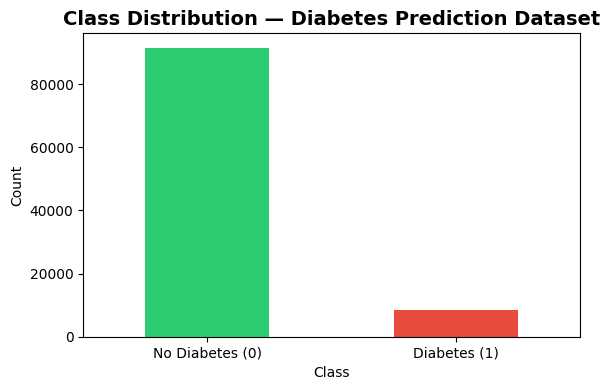

In [36]:
fig, ax = plt.subplots(figsize=(6, 4))
df["diabetes"].value_counts().plot(kind="bar", color=["#2ECC71", "#E74C3C"], ax=ax)

ax.set_xticklabels(["No Diabetes (0)", "Diabetes (1)"], rotation=0)
ax.set_title("Class Distribution — Diabetes Prediction Dataset", fontsize=14, fontweight="bold")
ax.set_xlabel("Class")
ax.set_ylabel("Count")

plt.tight_layout()
plt.savefig("class_distribution_diabetes_prediction.png", dpi=150)
plt.show()

In [37]:
df_encoded = df.copy()
for col in categorical_cols:
    df_encoded[col] = pd.factorize(df_encoded[col])[0]

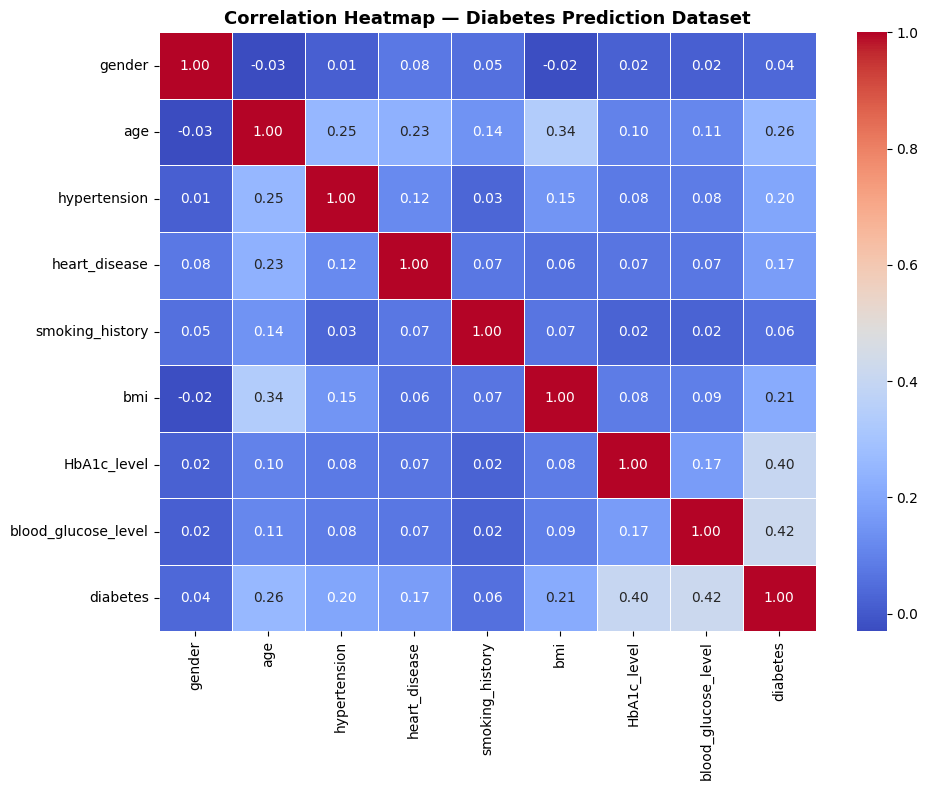

In [38]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df_encoded.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap — Diabetes Prediction Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap_diabetes_prediction.png', dpi=150)
plt.show()

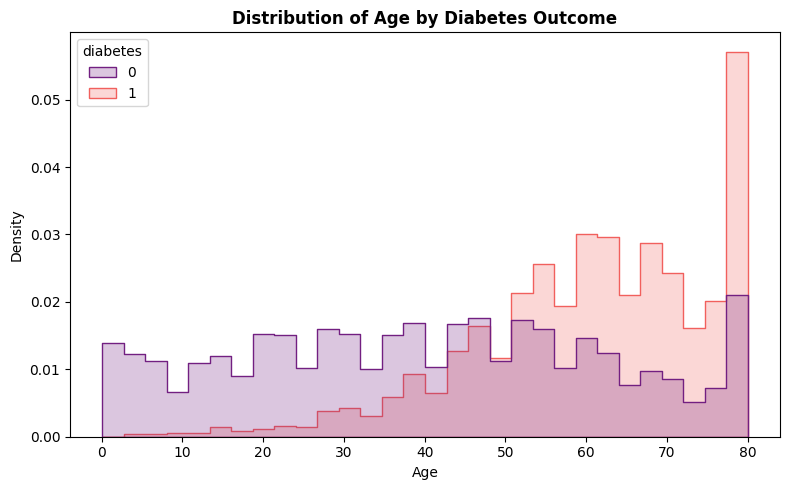

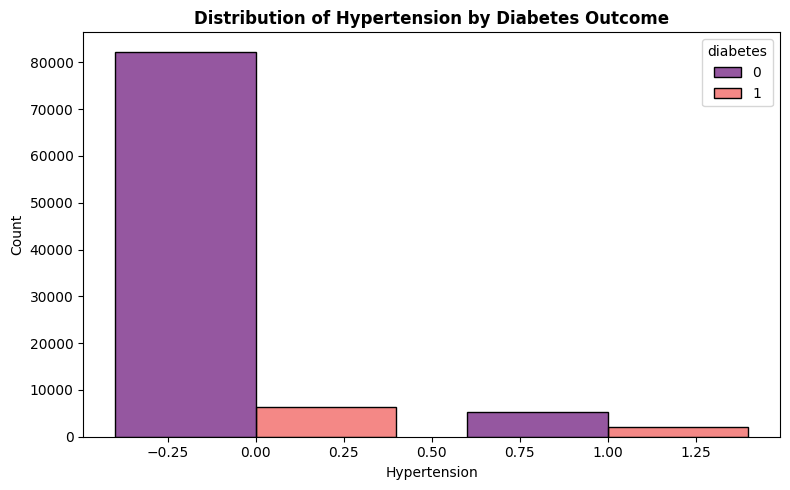

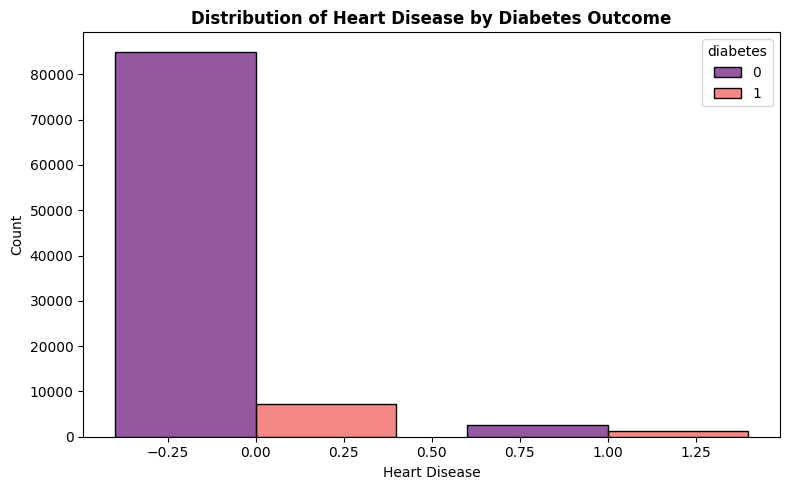

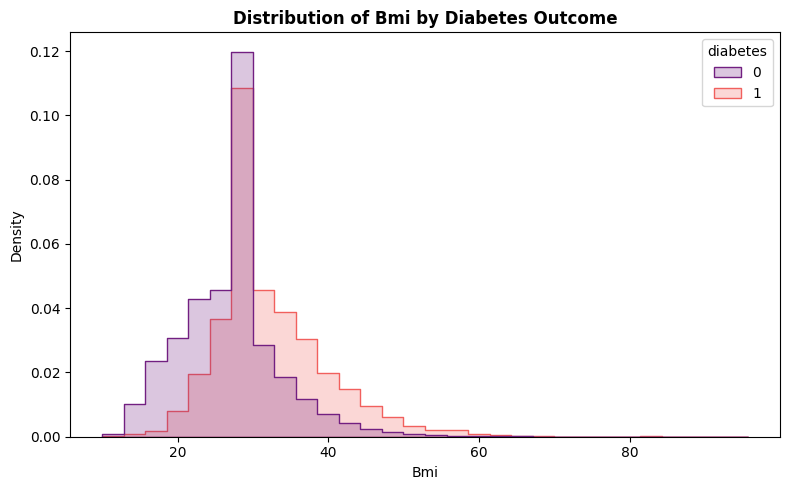

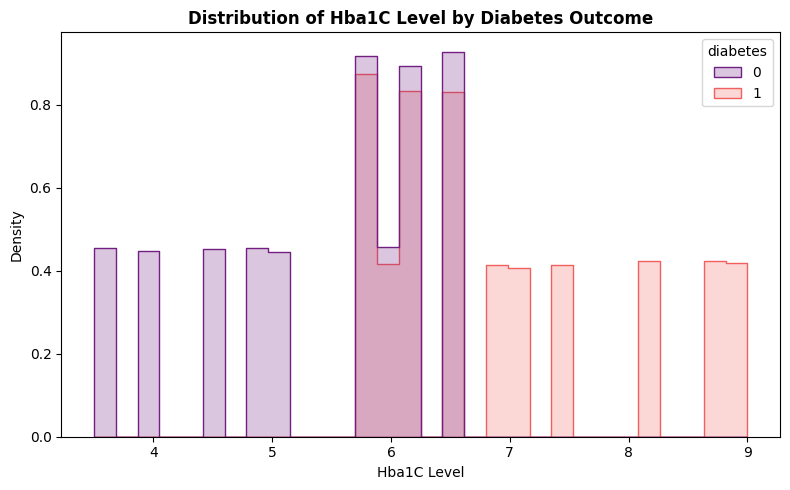

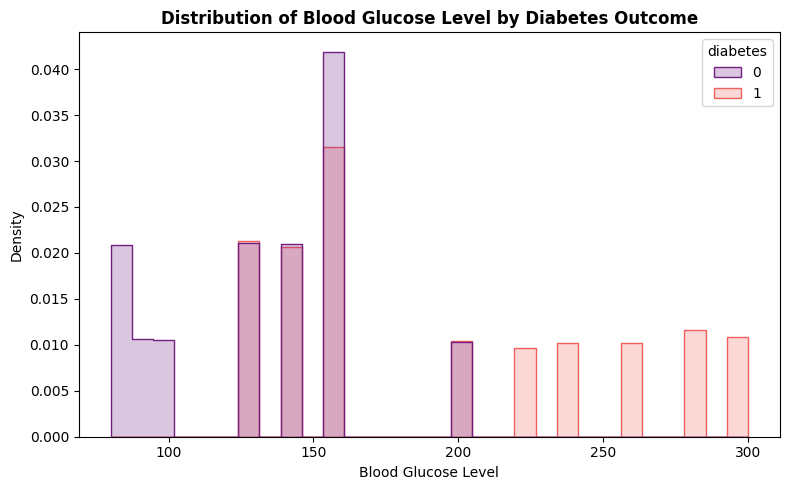

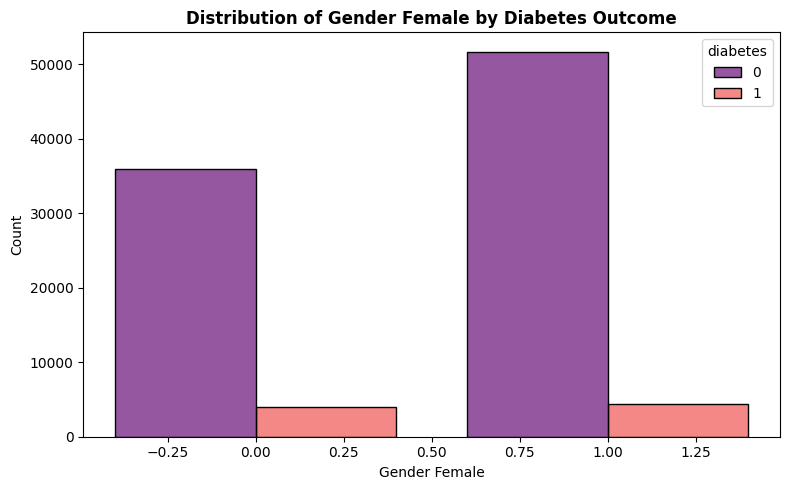

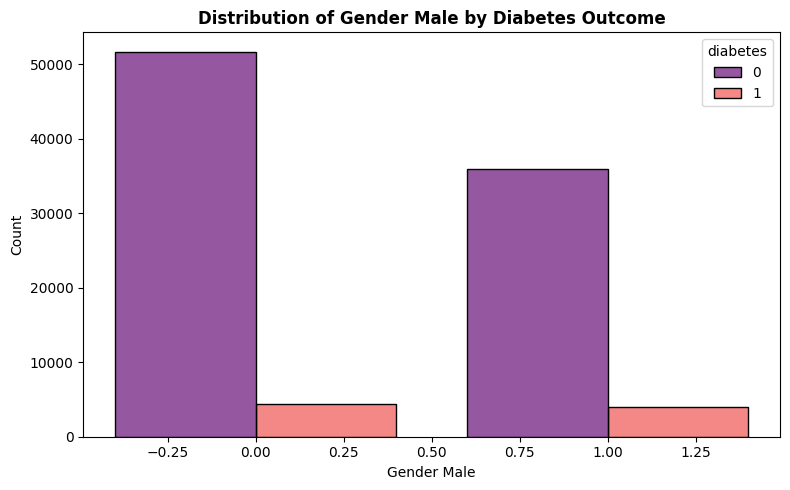

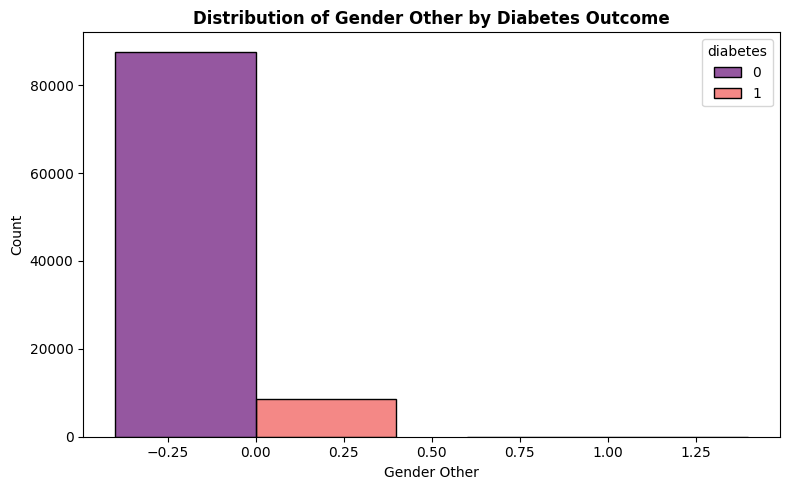

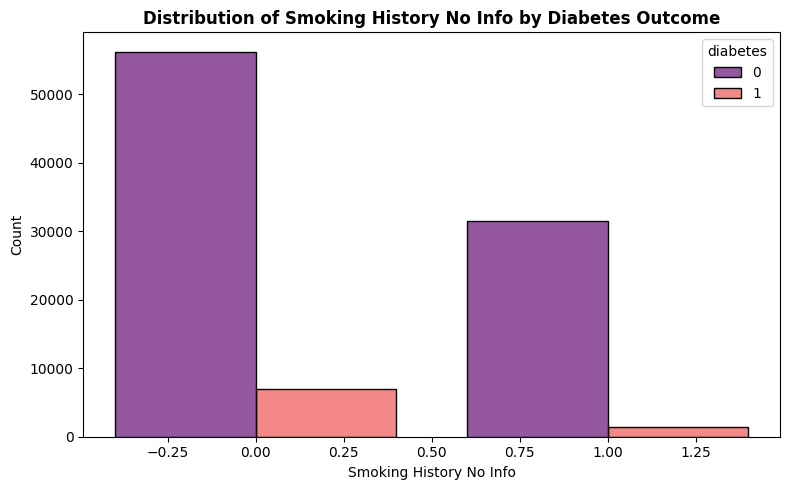

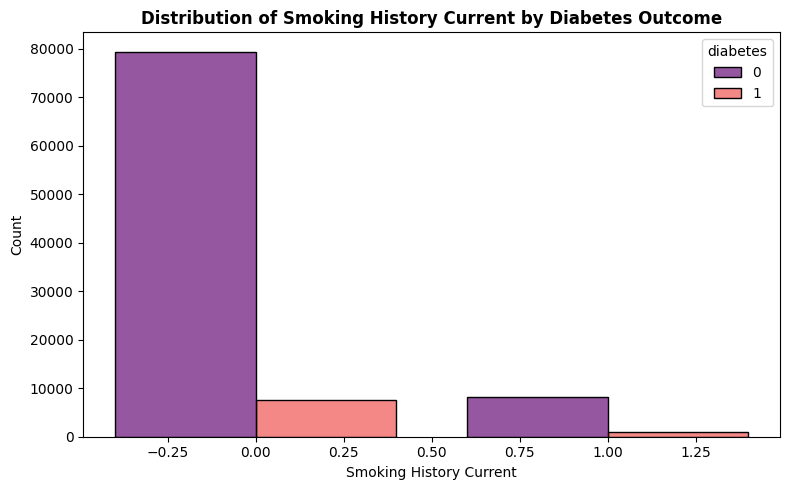

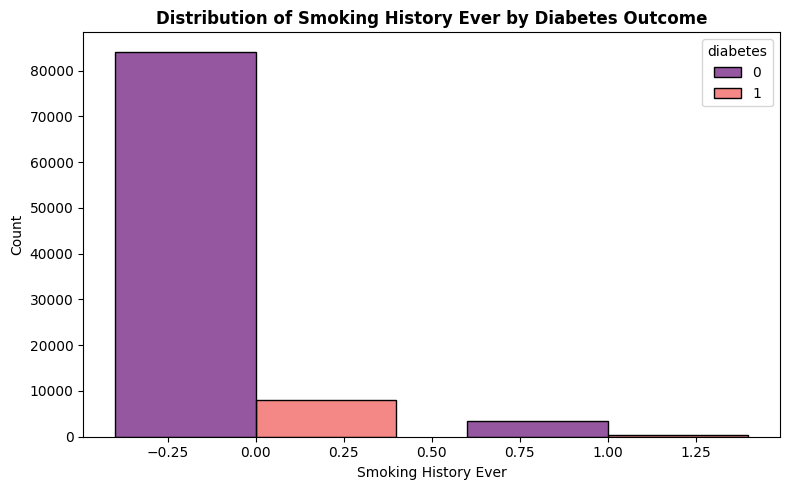

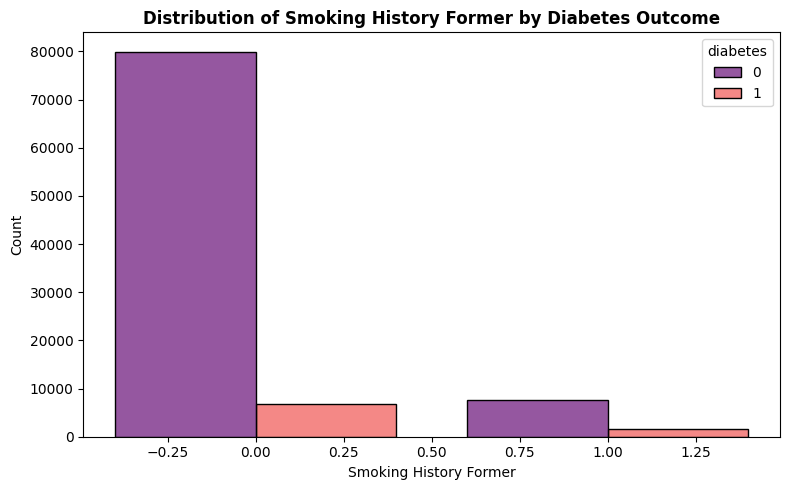

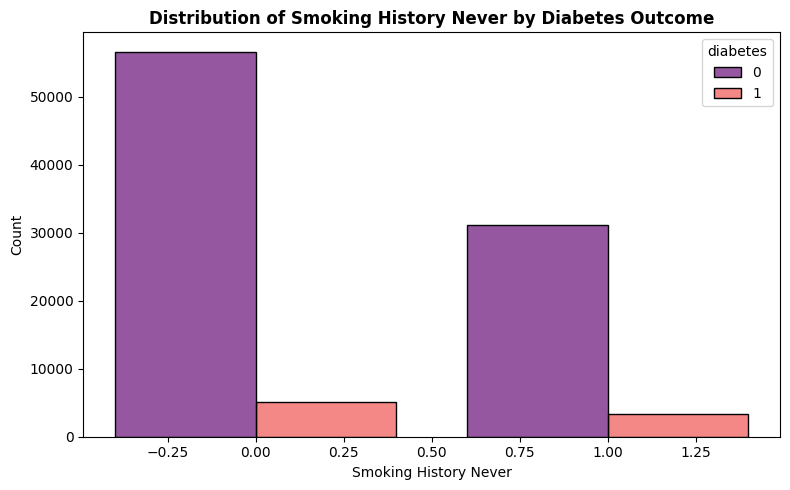

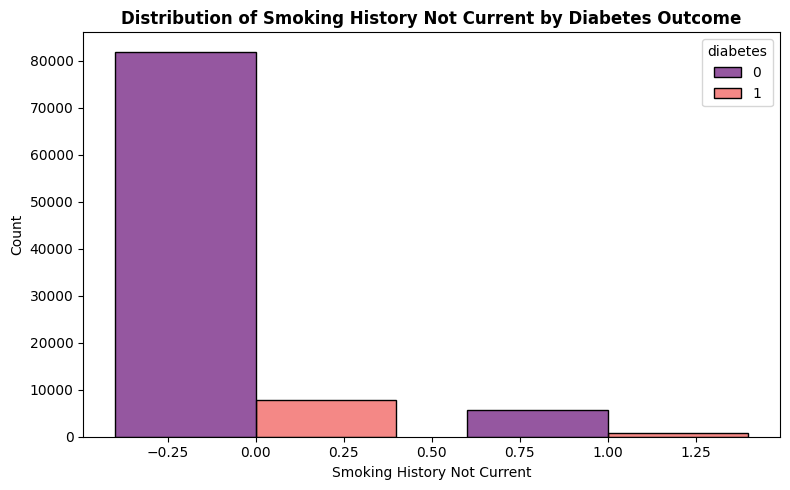

In [64]:
feature_columns = [col for col in df.columns if col != "diabetes"]

for col in feature_columns:
    plt.figure(figsize=(8, 5))

    if df[col].nunique() <= 10:
        sns.histplot(
            data=df,
            x=col,
            hue="diabetes",
            multiple="dodge",
            discrete=True,
            shrink=0.8,
            palette="magma"
        )
        plt.ylabel("Count")

    else:
        sns.histplot(
            data=df,
            x=col,
            hue="diabetes",
            bins=30,
            stat="density",
            common_norm=False,
            element="step",
            palette="magma"
        )
        plt.ylabel("Density")

    plt.title(f"Distribution of {col.replace('_', ' ').title()} by Diabetes Outcome", fontweight="bold")
    plt.xlabel(col.replace('_', ' ').title())
    plt.tight_layout()
    plt.show()



---


## Part 2: Preprocessing Pipeline
---



In [50]:
df = df.drop_duplicates().reset_index(drop=True)

print(f"Duplicates removed. New dataset shape: {df.shape}")

Duplicates removed. New dataset shape: (96146, 9)


In [51]:
print("-" * 50)
print(" One-Hot Encoding - Gender & Smoking History")
print("-" * 50)

cols_to_encode = ["gender", "smoking_history"]

existing_cols = [col for col in cols_to_encode if col in df.columns]

if not existing_cols:
    print("Original columns not found. They might already be encoded!")
else:
    for col in existing_cols:
        print(f"Processing: {col}")
        print(f"  Unique values: {df[col].unique()}")
        print(f"  Value counts:\n{df[col].value_counts()}\n")

df = pd.get_dummies(df, columns=cols_to_encode, drop_first=False)

new_cols = [c for c in df.columns if any(sub in c for sub in cols_to_encode)]
print("-" * 50)
print(f"New columns created: {new_cols}")
print(f"Shape after encoding: {df.shape}")
print("-" * 50)

--------------------------------------------------
 One-Hot Encoding - Gender & Smoking History
--------------------------------------------------
Processing: gender
  Unique values: ['Female' 'Male' 'Other']
  Value counts:
gender
Female    56161
Male      39967
Other        18
Name: count, dtype: int64

Processing: smoking_history
  Unique values: ['never' 'No Info' 'current' 'former' 'ever' 'not current']
  Value counts:
smoking_history
never          34398
No Info        32887
former          9299
current         9197
not current     6367
ever            3998
Name: count, dtype: int64

--------------------------------------------------
New columns created: ['gender_Female', 'gender_Male', 'gender_Other', 'smoking_history_No Info', 'smoking_history_current', 'smoking_history_ever', 'smoking_history_former', 'smoking_history_never', 'smoking_history_not current']
Shape after encoding: (96146, 16)
--------------------------------------------------


In [53]:
from sklearn.model_selection import train_test_split

#features (X) and target (y)
X = df.drop('diabetes', axis=1)
y = df['diabetes']

#test_size=0.2 saves 20% of data for the final evaluation
#stratify=y is used because only ~9% of data is diabetic
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Total rows in dataset:   {len(df)}")
print(f"Training set size:       {X_train.shape[0]} samples (80%)")
print(f"Test set size:           {X_test.shape[0]} samples (20%)")

print("\nClass Distribution - Training Set")
print(y_train.value_counts())

print("\nClass Distribution - Test Set")
print(y_test.value_counts())

Total rows in dataset:   96146
Training set size:       76916 samples (80%)
Test set size:           19230 samples (20%)

Class Distribution - Training Set
diabetes
0    70130
1     6786
Name: count, dtype: int64

Class Distribution - Test Set
diabetes
0    17534
1     1696
Name: count, dtype: int64


In [57]:
from sklearn.preprocessing import StandardScaler

#initialize
scaler = StandardScaler()

#fit on the training data then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#convert back to df
X_train_final = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_final = pd.DataFrame(X_test_scaled, columns=X.columns)

print("-" * 50)
print(" X_train statistics after scaling:")
print("-" * 50)
stats_summary = X_train_final.describe().T[['mean', 'std', 'min', 'max']]
print(stats_summary.round(2))

--------------------------------------------------
 X_train statistics after scaling:
--------------------------------------------------
                             mean  std   min    max
age                           0.0  1.0 -1.86   1.70
hypertension                  0.0  1.0 -0.29   3.44
heart_disease                 0.0  1.0 -0.21   4.84
bmi                          -0.0  1.0 -2.56  10.05
HbA1c_level                   0.0  1.0 -1.89   3.24
blood_glucose_level          -0.0  1.0 -1.42   3.96
gender_Female                -0.0  1.0 -1.18   0.85
gender_Male                  -0.0  1.0 -0.85   1.18
gender_Other                 -0.0  1.0 -0.01  74.11
smoking_history_No Info       0.0  1.0 -0.72   1.39
smoking_history_current      -0.0  1.0 -0.33   3.08
smoking_history_ever          0.0  1.0 -0.21   4.83
smoking_history_former       -0.0  1.0 -0.33   3.05
smoking_history_never        -0.0  1.0 -0.75   1.34
smoking_history_not current  -0.0  1.0 -0.27   3.75


In [58]:
from imblearn.over_sampling import SMOTE

#initialize
sm = SMOTE(random_state=42)

#apply to training data
X_train_resampled, y_train_resampled = sm.fit_resample(X_train_final, y_train)

print("-" * 50)
print(" CLASS BALANCE AFTER SMOTE")
print("-" * 50)
print(f"Original distribution:\n{y_train.value_counts(normalize=True).round(4)}")
print(f"\nResampled distribution:\n{y_train_resampled.value_counts(normalize=True)}")
print(f"\nNew Training Set Size: {X_train_resampled.shape[0]} samples")

--------------------------------------------------
 CLASS BALANCE AFTER SMOTE
--------------------------------------------------
Original distribution:
diabetes
0    0.9118
1    0.0882
Name: proportion, dtype: float64

Resampled distribution:
diabetes
0    0.5
1    0.5
Name: proportion, dtype: float64

New Training Set Size: 140260 samples


In [62]:
path = "data/preprocessed/diabetes_prediction_dataset_preprocessed"

try:
    # save Features (X) as Parquet (too big for github needed to shrink)
    X_train_resampled.to_parquet(f"{path}/X_train_scaled_smote.parquet", index=False)
    X_test_final.to_parquet(f"{path}/X_test_scaled.parquet", index=False)

    #save Targets (y) as Parquet
    y_train_resampled.to_frame().to_parquet(f"{path}/y_train_smote.parquet", index=False)
    y_test.to_frame().to_parquet(f"{path}/y_test.parquet", index=False)

    print("-" * 50)
    print(" preprocessing complete!")
    print("-" * 50)
    print(f"Location: {path}")
    print("Files: X_train_scaled_smote.parquet, y_train_smote.parquet, etc.")

except Exception as e:
    print(f"Failed to save dataset: {e}")

--------------------------------------------------
 preprocessing complete!
--------------------------------------------------
Location: data/preprocessed/diabetes_prediction_dataset_preprocessed
Files: X_train_scaled_smote.parquet, y_train_smote.parquet, etc.
